# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Muhammad Rafiqi Raihan Imaratul Huda
- Email: rafiqiraihan20@gmail.com
- Id Dicoding: rafiqiraihan

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

### Menyiapkan data yang akan diguankan

In [2]:
# Load data
df = pd.read_csv('data.csv', sep=";")
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
# Cek apakah ada dataset kosong
df.isnull().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


In [5]:
df.describe(include="all")

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


### EDA

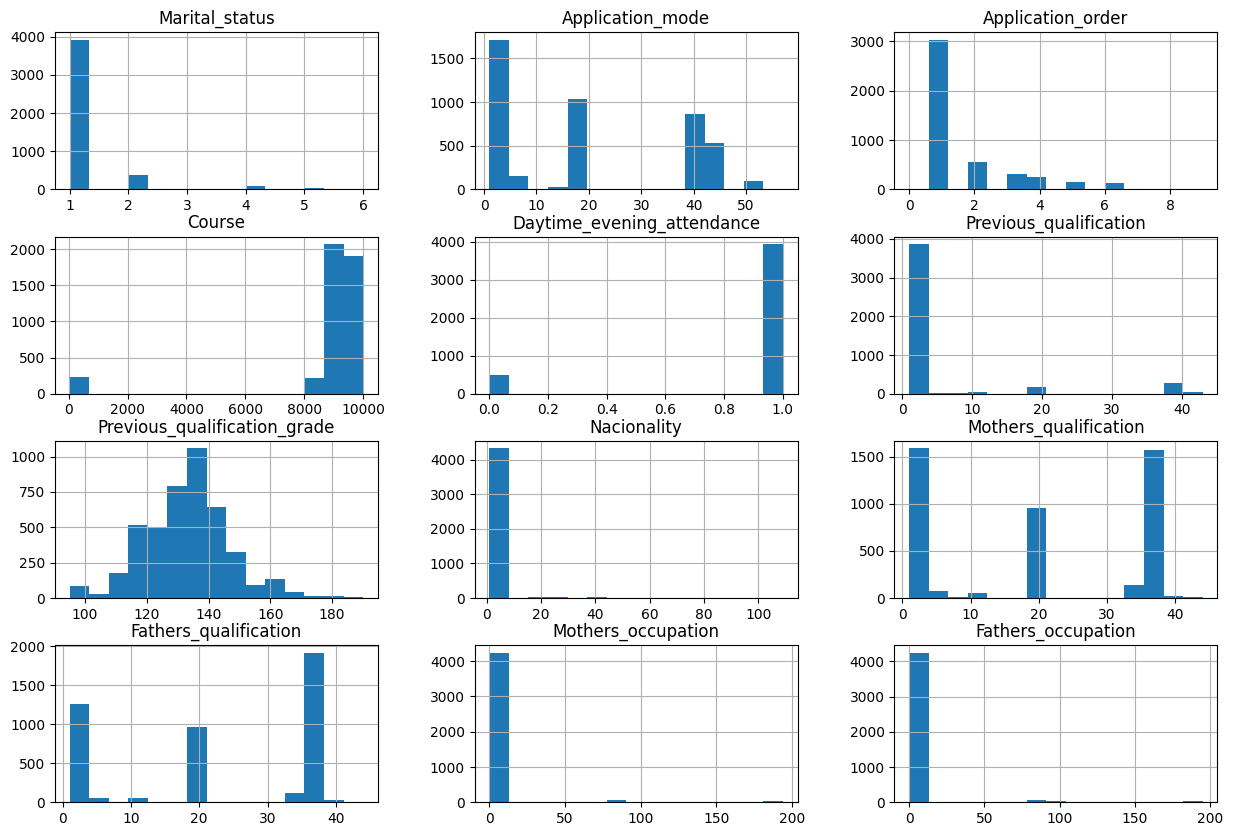

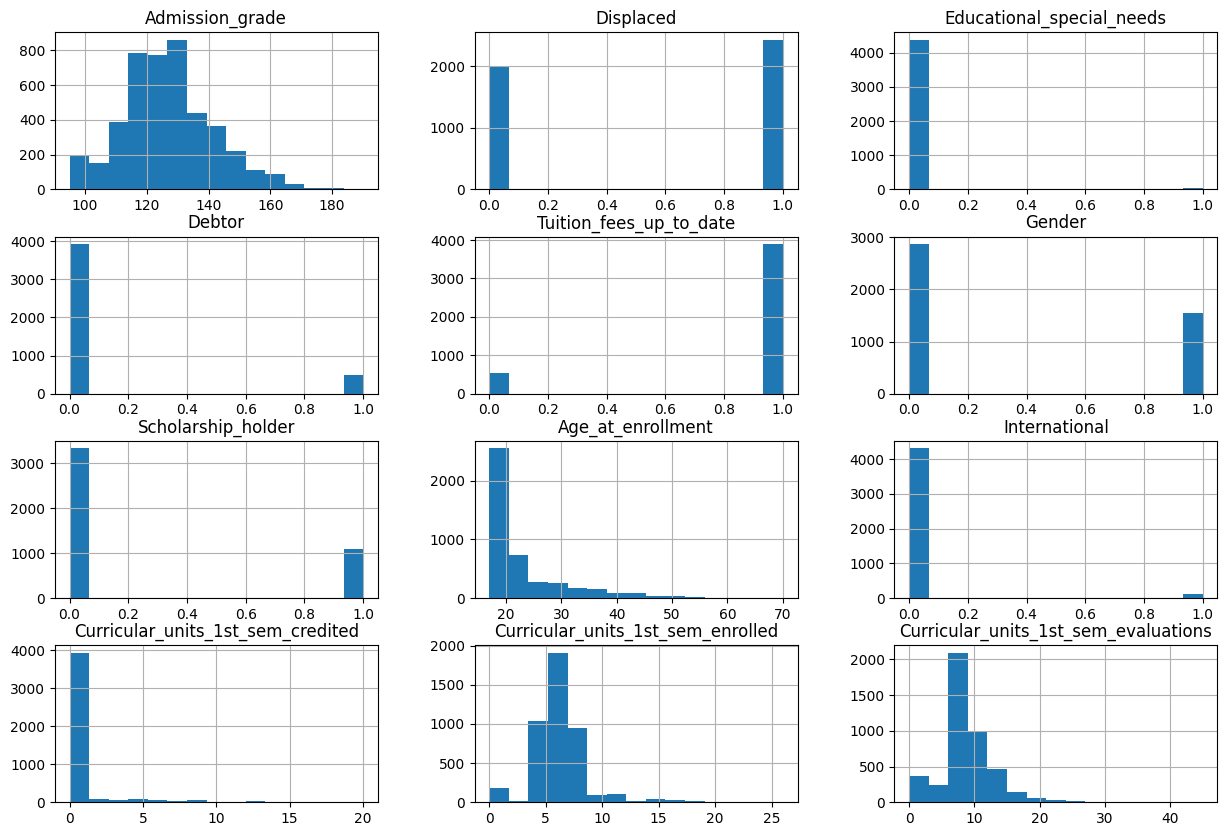

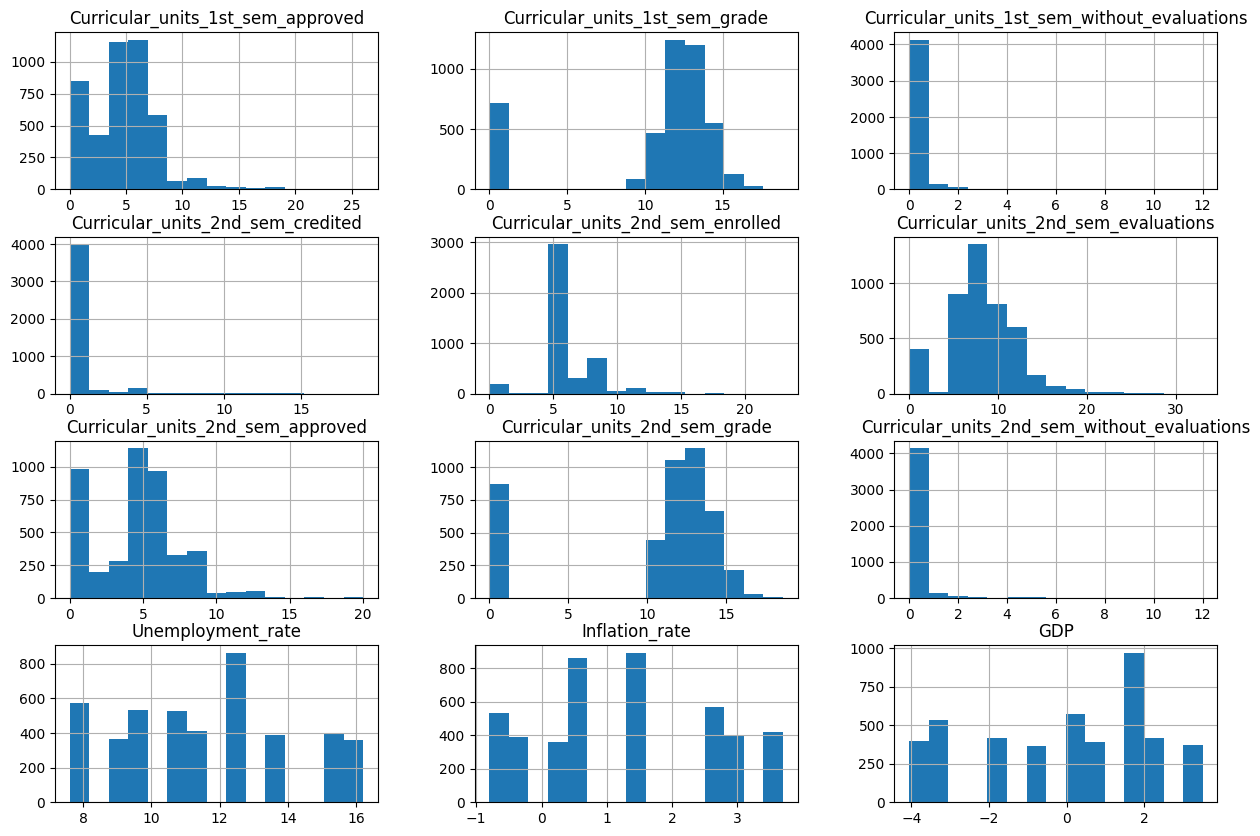

In [6]:
numerical_features = df.select_dtypes(include='number').columns

chunks = np.array_split(numerical_features, 3)

for cols in chunks:
    df[cols].hist(figsize=(15, 10), bins=15)
    plt.show()

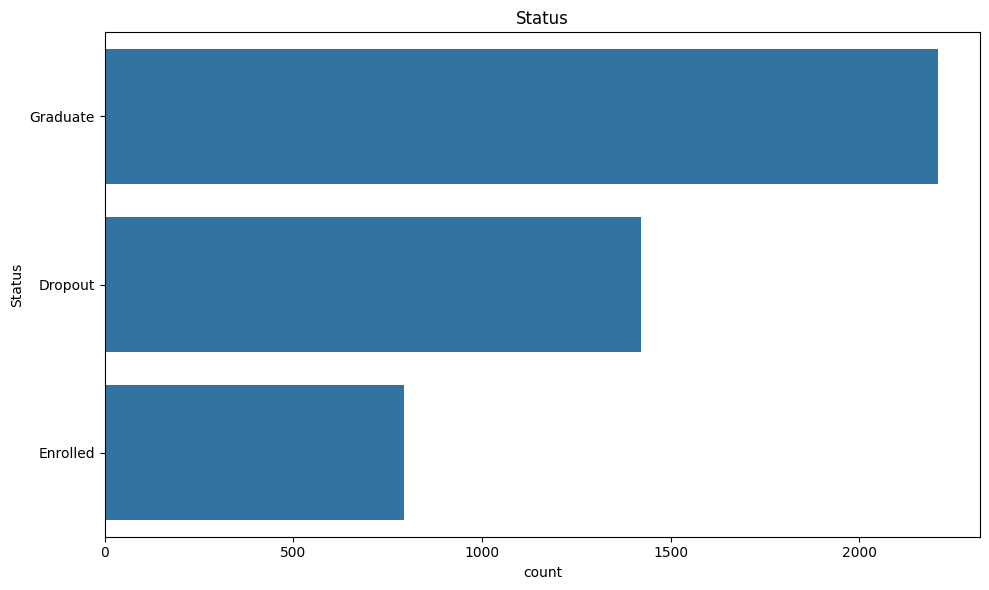

In [7]:
categorical_features = df.select_dtypes(include=['object', 'category']).columns

for feature in categorical_features:
    top_categories = df[feature].value_counts().index

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df[df[feature].isin(top_categories)],
        y=feature,
        order=top_categories
    )

    plt.title(f"{feature}")
    plt.tight_layout()
    plt.show()

### Multivariate Analysis

In [8]:
# Karena semua data bertipe numerik jadi hanya numerik saja yang di analisis

def numerical_plot(features, df, segment_feature=None, top_n=10):
    import math

    n_cols = 2
    n_rows = math.ceil(len(features) / n_cols)

    fig, ax = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
    ax = ax.flatten()

    for i, feature in enumerate(features):

        if segment_feature:
            sns.boxplot(
                data=df,
                x=segment_feature,
                y=feature,
                ax=ax[i]
            )
        else:
            sns.histplot(
                data=df,
                x=feature,
                bins=30,
                kde=True,
                ax=ax[i]
            )

        ax[i].set_title(feature)

    plt.tight_layout()
    plt.show()

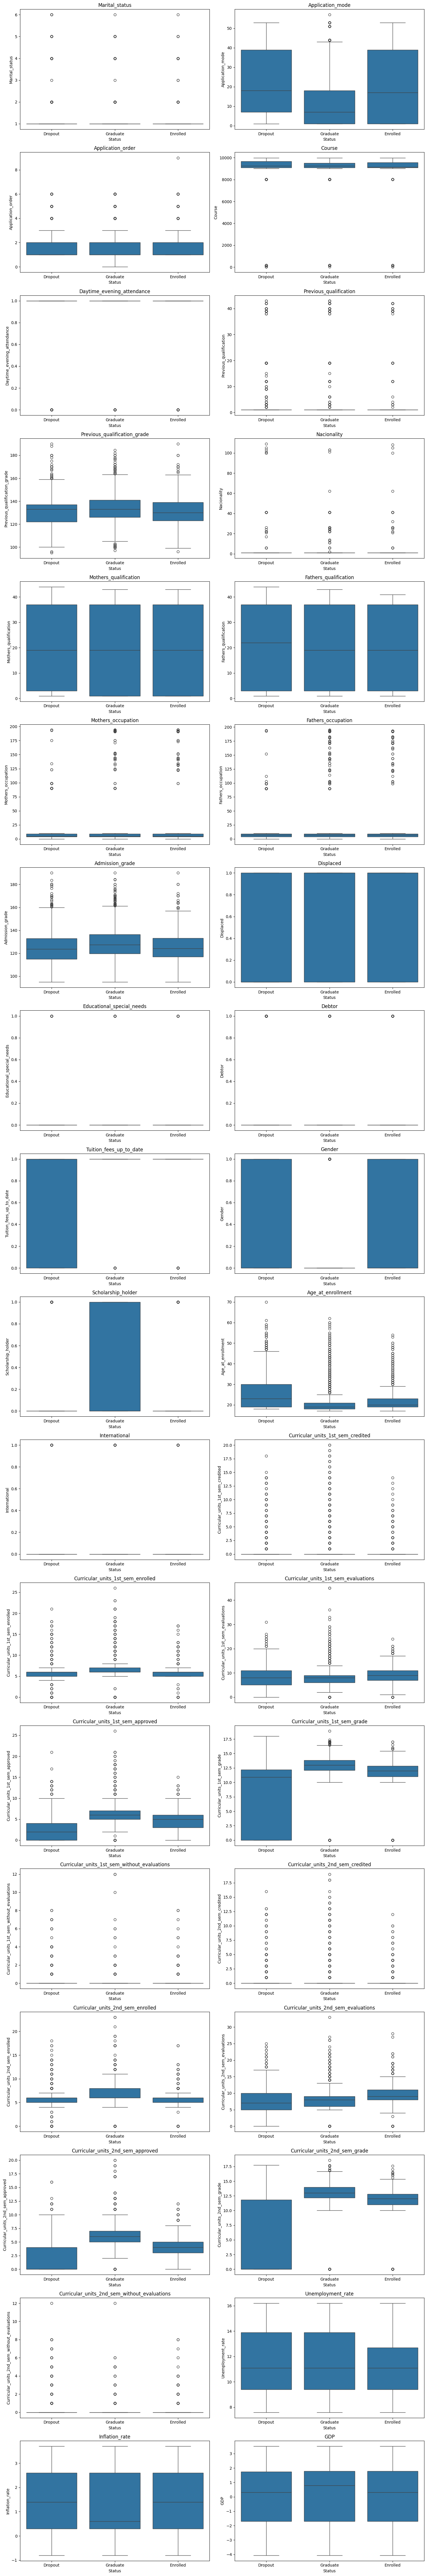

In [9]:
numerical_plot(
    features=numerical_features,
    df=df,
    segment_feature='Status'
)

## Data Preparation / Preprocessing

In [10]:
# Membuat target baru yaitu is_dropout
df['is_dropout'] = df['Status'].apply(
    lambda x: 1 if x == 'Dropout' else 0
)

df = df.drop(['Status'], axis=1)

In [11]:
# Pisahkan target
X = df.drop(['is_dropout'], axis=1)
y = df['is_dropout']

In [12]:
categorical_cols = [
    'Marital_status',
    'Application_mode',
    'Course',
    'Daytime_evening_attendance',
    'Previous_qualification',
    'Nacionality',
    'Mothers_qualification',
    'Fathers_qualification',
    'Mothers_occupation',
    'Fathers_occupation',
    'Displaced',
    'Educational_special_needs',
    'Debtor',
    'Tuition_fees_up_to_date',
    'Gender',
    'Scholarship_holder',
    'International'
]

In [13]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [14]:
le = LabelEncoder()

y = le.fit_transform(y)

In [15]:
print(le.classes_)

[0 1]


In [16]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

## Modeling

In [18]:
model_rf = RandomForestClassifier(
    n_estimators=500,
    random_state=123,
    class_weight='balanced'
)

model_rf.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=123)

## Evaluation

In [19]:
y_pred_rf = model_rf.predict(X_test)

In [20]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89       569
           1       0.83      0.74      0.78       316

    accuracy                           0.85       885
   macro avg       0.85      0.83      0.84       885
weighted avg       0.85      0.85      0.85       885



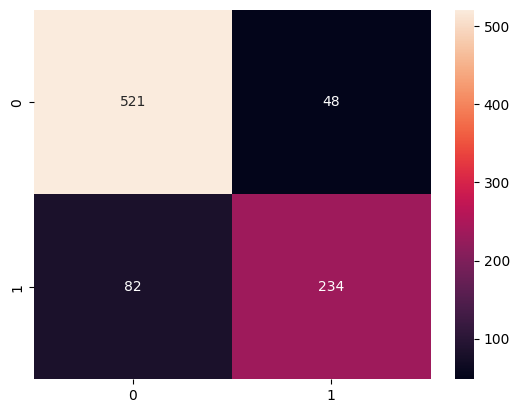

In [21]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [22]:
feature_importance = pd.Series(
    model_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(20))

Curricular_units_2nd_sem_approved       0.141935
Curricular_units_1st_sem_approved       0.095282
Curricular_units_2nd_sem_grade          0.091891
Curricular_units_1st_sem_grade          0.053791
Curricular_units_2nd_sem_evaluations    0.035187
Age_at_enrollment                       0.028867
Curricular_units_1st_sem_evaluations    0.028631
Admission_grade                         0.028271
Debtor_1                                0.027654
Previous_qualification_grade            0.027606
Gender_1                                0.021548
Curricular_units_2nd_sem_enrolled       0.020975
Tuition_fees_up_to_date_1               0.020863
GDP                                     0.020520
Unemployment_rate                       0.018988
Curricular_units_1st_sem_enrolled       0.018547
Inflation_rate                          0.018116
Application_mode_39                     0.012702
Course_9853                             0.009704
Application_order                       0.009136
dtype: float64


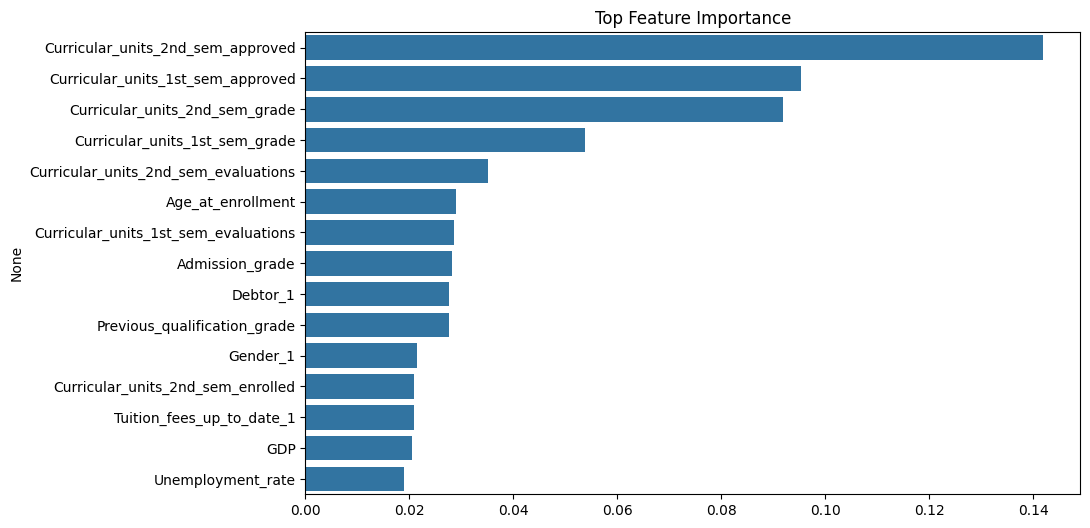

In [23]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top Feature Importance")
plt.show()

In [24]:
import joblib

joblib.dump(model_rf, 'model_rf.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [25]:
feature_columns = X.columns.tolist()

joblib.dump(feature_columns, 'feature_columns.pkl')

['feature_columns.pkl']

In [26]:
df['is_dropout'] = df['is_dropout'].map({
    1: 'Dropout',
    0: 'Not Dropout'
})

In [38]:
df['Curricular_units_1st_sem_grade'].describe()

count    4424.000000
mean       10.640822
std         4.843663
min         0.000000
25%        11.000000
50%        12.285714
75%        13.400000
max        18.875000
Name: Curricular_units_1st_sem_grade, dtype: float64